In [1]:
import networkx as nx
import itertools
import collections
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from scipy.optimize import curve_fit

# A large network data repository
https://networks.skewed.de


In [2]:
#import the dataset
from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen

#https://networks.skewed.de/net/hyves
address="https://networks.skewed.de/net/hyves/files/hyves.csv.zip"
resp=urlopen(address)
zipfile = ZipFile(BytesIO(resp.read()))
strf=zipfile.read("edges.csv").decode().split("\n")

#G= nx.Graph()
#for line in strf[1:]:
#    try:
#        ll=line.rstrip().split(",")
#        G.add_edge(ll[0],ll[1])
#    except :
#        continue

G= nx.parse_edgelist(strf,delimiter=",",data=True)
G = G.to_undirected()


### NETWORK INFO

In [3]:
print(G.number_of_nodes())
print(G.number_of_edges())
print(nx.density(G))
print(nx.is_connected(G))

1402673
2777419
2.8233117313770165e-06
True


### BINNING AND POWER LAW FITTING FUNCTIONS

In [4]:
def logBinning(degreeList,nbin):
    kmin=min(degreeList)
    kmax=max(degreeList)
    logBins = np.logspace(np.log10(kmin), np.log10(kmax),num=nbin)
    logBinDensity, binedges = np.histogram(degreeList, bins=logBins, density=True)
    logBins = np.delete(logBins, -1)
    return logBinDensity, logBins

In [5]:
def powerLaw(x, a, b):
    return b*x**(a)

### DEGREE DISTRIBUTION

In [6]:
kDict=dict(G.degree())

In [7]:
kValues=list(kDict.values())

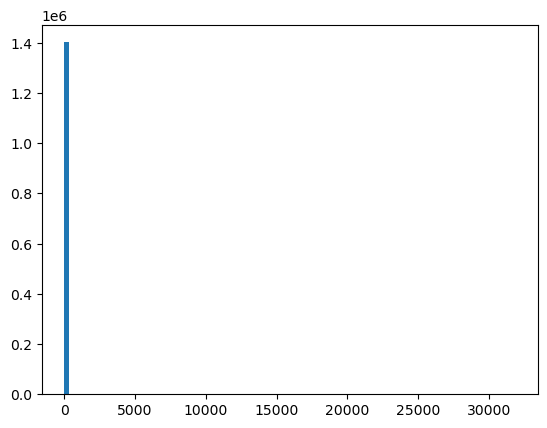

In [8]:
plt.hist(kValues,bins=100)
plt.show()

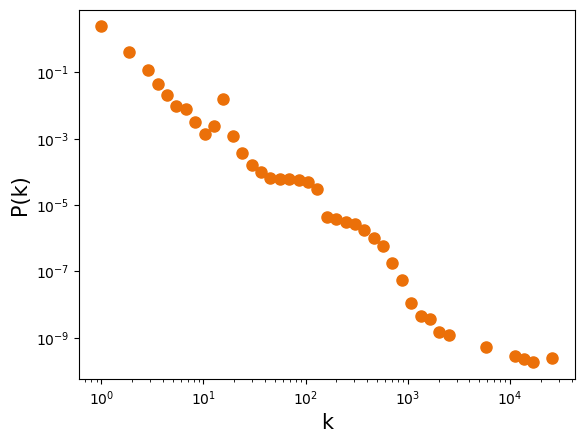

In [9]:
#https://www.computerhope.com/tips/tip143.htm

pk,k=logBinning(kValues,50)
plt.loglog(k,pk,'o',color='#EB7009',markersize=8)
plt.xlabel('k',size=15)
plt.ylabel('P(k)',size=15)
plt.show()

In [10]:
from scipy.optimize import curve_fit
import scipy.stats

fitx=[u for (u,v) in zip(k,pk) if (u>70 and u<1000)]
fity=[v for (u,v) in zip(k,pk) if (u>70 and u<1000)]

popt, pcov = curve_fit(powerLaw, fitx, fity)  
print (popt[0])

-2.3281916408608327


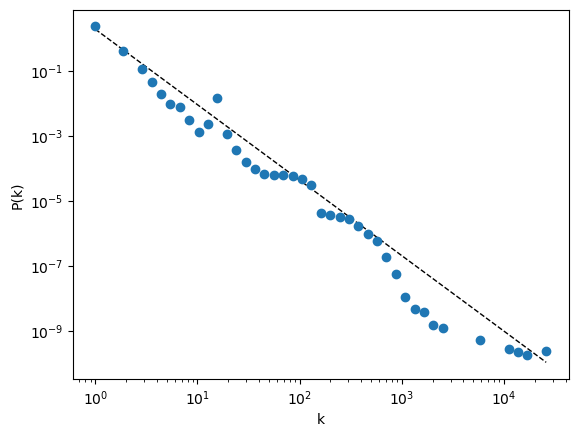

In [11]:
plt.loglog(sorted(k), powerLaw(sorted(k), *popt), '--',c='k',linewidth=1)

plt.loglog(k,pk,'o')
plt.xlabel('k')
plt.ylabel('P(k)')
plt.show()

### DEGREE MIXING

In [12]:
#we calculate the average degree of the neighbours for each node
knn={}
for n in G.nodes():
    neighbors_degrees=[kDict[v] for v in G.neighbors(n)]
    knn[n]=np.mean(neighbors_degrees)


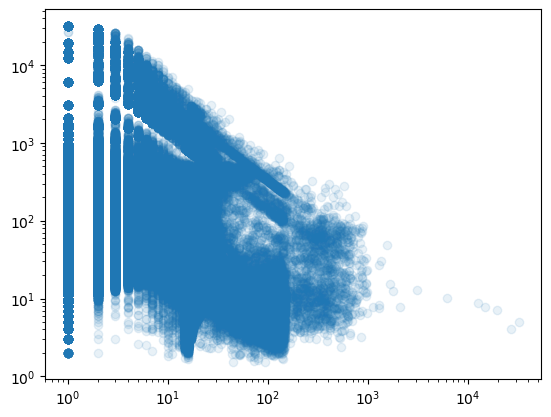

In [ ]:
#we plot knn as a function of k 
xx=[]
yy=[]
for n in knn.keys():
    xx.append(kDict[n])
    yy.append(knn[n])

plt.loglog(xx,yy,'o',alpha=0.1)

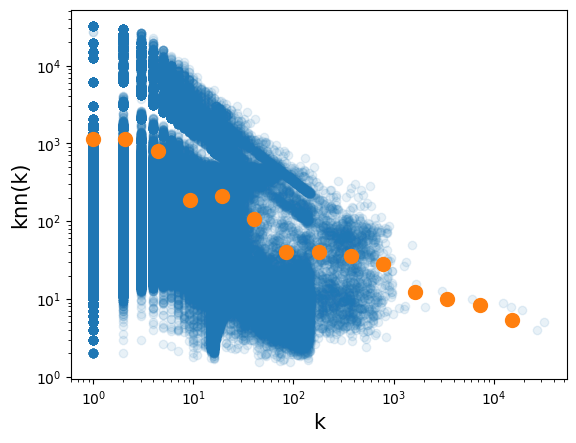

In [14]:
# we bin the data in logarithmic bins and we plot the average knn for each bin
xx=[]
yy=[]
for n in knn.keys():
    xx.append(kDict[n])
    yy.append(knn[n])

plt.loglog(xx,yy,'o',alpha=0.1)
logBins=np.logspace(np.log2(np.min(xx)),np.log2(np.max(xx)),base=2,num=15)
#if I use np.linspace I will have linear bins
ybin,xbin,binnumber=scipy.stats.binned_statistic(xx,yy,statistic='mean',bins=logBins)
plt.loglog(xbin[:-1],ybin,'o',markersize=10)

plt.xlabel('k',size=15)
plt.ylabel('knn(k)',size=15)
plt.show()

# RICH CLUB

In [15]:
rc = nx.rich_club_coefficient(G, normalized=False, seed=42)

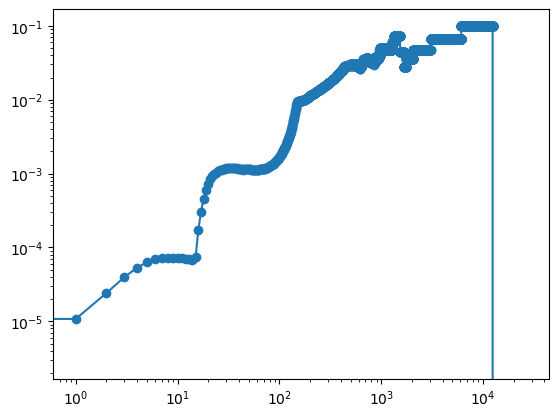

In [16]:
plt.loglog(rc.keys(),rc.values(),'o-')

# ROBUSTNESS

### RANDOM FAILURE

In [167]:
nodes_small=[i for i in G.nodes() if G.degree(i)>100]

In [168]:
len(nodes_small)

4949

In [169]:
Gs=G.subgraph(nodes_small)

In [171]:
fList=np.linspace(0,1,20)
NtoRem=[int(i*Gs.number_of_nodes()) for i in fList]

In [172]:
fList

array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ])

In [173]:
print(NtoRem)

[0, 260, 520, 781, 1041, 1302, 1562, 1823, 2083, 2344, 2604, 2865, 3125, 3386, 3646, 3907, 4167, 4428, 4688, 4949]


In [174]:
import random
sf=[]
for nn in NtoRem[:-1]:
    thisG=Gs.copy()
    ll=random.sample(list(Gs.nodes()),nn)
    thisG.remove_nodes_from(ll)
    thisSf=len(max(sorted(nx.connected_components(thisG), key = len, reverse=True)))
    sf.append(thisSf/float(Gs.number_of_nodes()))


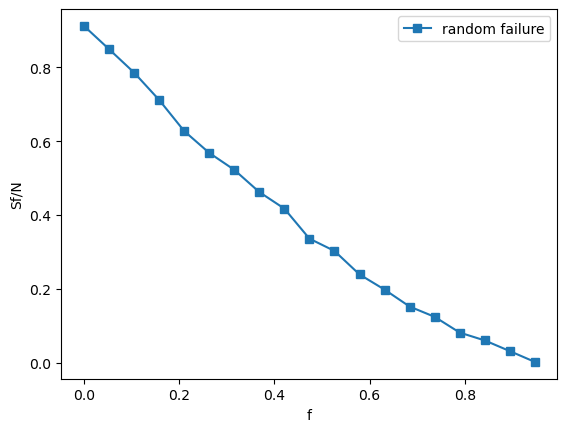

In [175]:

plt.plot(fList[:-1],sf,'s-',label='random failure')
plt.xlabel('f')
plt.ylabel('Sf/N')
plt.legend()
plt.show()

### TARGET ATTACK

In [176]:
hh=collections.Counter(dict(Gs.degree())).most_common()
orderedNodes=[u for (u,v) in hh]

In [177]:
fList1=np.linspace(0,1,20)
NtoRem=[int(i*Gs.number_of_nodes()) for i in fList1]

In [178]:
sfAtt=[]
for nn in NtoRem[:-1]:
    thisG=Gs.copy()
    ll=orderedNodes[:nn]
    thisG.remove_nodes_from(ll)
    thisSf=len(max(sorted(nx.connected_components(thisG), key = len, reverse=True)))
    sfAtt.append(thisSf/float(Gs.number_of_nodes()))

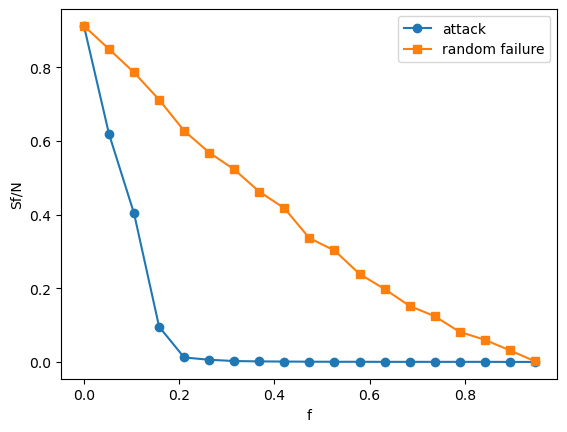

In [179]:
plt.plot(fList1[:-1],sfAtt,'o-',label='attack')
plt.plot(fList[:-1],sf,'s-',label='random failure')
plt.xlabel('f')
plt.ylabel('Sf/N')
plt.legend()
plt.show()

# BIPARTITE NETWORKS

https://sites.google.com/site/yangdingqi/home/foursquare-dataset

### a rapid way to generate bipartite graphs

In [21]:
infile='data/foursquareNY_TOKYO/dataset_TSMC2014_NYC.txt'


In [35]:
df=pd.read_csv(infile,sep='\t',encoding='latin-1',header=None,names=['user_id','location_id','location_type','latitude','longitude','timezone','timestamp'])

In [36]:
df

,user_id,location_id,location_type,latitude,longitude,timezone,timestamp
470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012
...,...,...,...,...,...,...,...
688,3fd66200f964a52000e71ee3,4bf58dd8d48988d1e7931735,Music Venue,40.733596,-74.003139,-300,Sat Feb 16 02:29:11 +0000 2013
560,4bca32ff0687ef3be789dbcc,4bf58dd8d48988d16c941735,Burger Joint,40.745719,-73.993720,-300,Sat Feb 16 02:31:35 +0000 2013
945,50a77716e4b0b5a9492f6f56,4bf58dd8d48988d103941735,Home (private),40.854364,-73.883070,-300,Sat Feb 16 02:33:16 +0000 2013
671,4514efe0f964a520e7391fe3,4bf58dd8d48988d11d941735,Bar,40.735981,-74.029309,-300,Sat Feb 16 02:34:31 +0000 2013


In [42]:
dfagg=df.groupby('user_id',as_index=False)['location_id'].agg(list).rename(columns={'location_id':'checkins'})

In [43]:
dfagg

,user_id,checkins
0,3fd66200f964a52000e71ee3,"[4bf58dd8d48988d1e7931735, 4bf58dd8d48988d1e79..."
1,3fd66200f964a52000e81ee3,"[4bf58dd8d48988d176941735, 4bf58dd8d48988d1769..."
2,3fd66200f964a52000f11ee3,[4bf58dd8d48988d1e4931735]
3,3fd66200f964a52001e51ee3,[4bf58dd8d48988d118941735]
4,3fd66200f964a52001e81ee3,"[4bf58dd8d48988d11d941735, 4bf58dd8d48988d11d9..."
...,...,...
38328,51190f52e4b0f83278d5b9ba,[4bf58dd8d48988d104941735]
38329,51194e17e4b0665cf3280ce3,[4bf58dd8d48988d127941735]
38330,511aa583e4b03acfa105f50b,[4e0e22f5a56208c4ea9a85a0]
38331,511ae28ce4b00516bc52ccae,[4bf58dd8d48988d103941735]


In [44]:
dfagg['n_checkins']=dfagg['checkins'].apply(lambda x: len(x))

In [46]:
dfagg=dfagg[dfagg['n_checkins']>1]

In [47]:
dfagg

,user_id,checkins,n_checkins
0,3fd66200f964a52000e71ee3,"[4bf58dd8d48988d1e7931735, 4bf58dd8d48988d1e79...",16
1,3fd66200f964a52000e81ee3,"[4bf58dd8d48988d176941735, 4bf58dd8d48988d1769...",2
4,3fd66200f964a52001e81ee3,"[4bf58dd8d48988d11d941735, 4bf58dd8d48988d11d9...",17
5,3fd66200f964a52002eb1ee3,"[4bf58dd8d48988d1e7931735, 4bf58dd8d48988d1e79...",3
6,3fd66200f964a52003e51ee3,"[4bf58dd8d48988d118941735, 4bf58dd8d48988d1189...",5
...,...,...,...
38311,5112e1bae4b0c5cbb0b75ffb,"[4bf58dd8d48988d11a941735, 4bf58dd8d48988d11a9...",2
38312,51132cdae4b03a1e6d5da952,"[4d954b06a243a5684965b473, 4d954b06a243a568496...",2
38315,51140198e4b0874a568cde81,"[4bf58dd8d48988d162941735, 4bf58dd8d48988d1629...",13
38320,5114f07ce4b0922f3049c3d5,"[4bf58dd8d48988d124941735, 4bf58dd8d48988d1249...",2


In [49]:
import itertools
dfagg['edges']=dfagg['checkins'].apply(lambda x: list(itertools.combinations(x,2)))

/var/folders/1n/j534p4sn2yl7fgjy8bv2l5zm0000gn/T/ipykernel_18273/4194119283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfagg['edges']=dfagg['checkins'].apply(lambda x: list(itertools.combinations(x,2)))


In [51]:
def flatten(l):
    return [item for sublist in l for item in sublist]

In [52]:
edges=flatten(dfagg['edges'].tolist())

In [53]:
G=nx.Graph()
G.add_edges_from(edges)

In [55]:
G.number_of_edges()

573